# 1. EDA

### 1.1  Setup & imports

In [10]:
import pandas as pd
from pathlib import Path
import numpy as np 
import matplotlib.pyplot as plt

### 1.2 Loading the dataset


In [2]:
df = pd.read_csv("../Dataset/clean/interactions_clean.csv")

### 1.3 Data exploration

In [3]:
df.shape

(17340, 6)

In [4]:
df.head()

,Student ID,Question ID,difficulty,correct,Response Time,topic
0,AQklHbi5bt8l,1,hard,0,27232,Data Mining Tasks
1,AQklHbi5bt8l,2,easy,1,8933,Similarity Measures
2,AQklHbi5bt8l,3,easy,1,14965,Similarity Measures
3,AQklHbi5bt8l,4,easy,1,12691,Similarity Measures
4,AQklHbi5bt8l,5,medium,0,26452,Similarity Measures


In [5]:
df.dtypes

Student ID       object
Question ID       int64
difficulty       object
correct           int64
Response Time     int64
topic            object
dtype: object

- unique values in each column

In [7]:
for column in df.columns:
    print(f"{column}: {df[column].nunique()}")

Student ID: 121
Question ID: 150
difficulty: 3
correct: 2
Response Time: 3884
topic: 25


- unique topics

In [8]:
df["topic"].unique()

array(['Data Mining Tasks', 'Similarity Measures', 'Time Series Data',
       'Data Types', 'Programming Tools (NumPy/Pandas)',
       'Unsupervised Learning', 'Data Preprocessing',
       'Scaling & Normalization', 'Feature Selection',
       'Feature Extraction', 'Principal Component Analysis',
       'Decision Trees', 'K-means Clustering', 'Hierarchical Clustering',
       'DBSCAN', 'Model Evaluation', 'Clustering Evaluation',
       'Classification', 'Overfitting & Regularization',
       'Cross-Validation', 'Association Rules', 'Apriori Algorithm',
       'FP-growth', 'Rule Metrics', 'General'], dtype=object)

- distribution of each value

In [16]:
topic_counts = df["topic"].value_counts()
print (topic_counts)

topic
Decision Trees                      2394
Association Rules                   1792
Data Types                          1625
Principal Component Analysis        1428
Feature Selection                   1309
DBSCAN                               936
K-means Clustering                   932
Similarity Measures                  819
Unsupervised Learning                814
Hierarchical Clustering              585
Model Evaluation                     577
Data Mining Tasks                    472
Programming Tools (NumPy/Pandas)     468
Overfitting & Regularization         452
Classification                       452
Cross-Validation                     339
Apriori Algorithm                    336
Rule Metrics                         336
Clustering Evaluation                234
Data Preprocessing                   234
Scaling & Normalization              234
FP-growth                            224
Feature Extraction                   119
Time Series Data                     117
General   

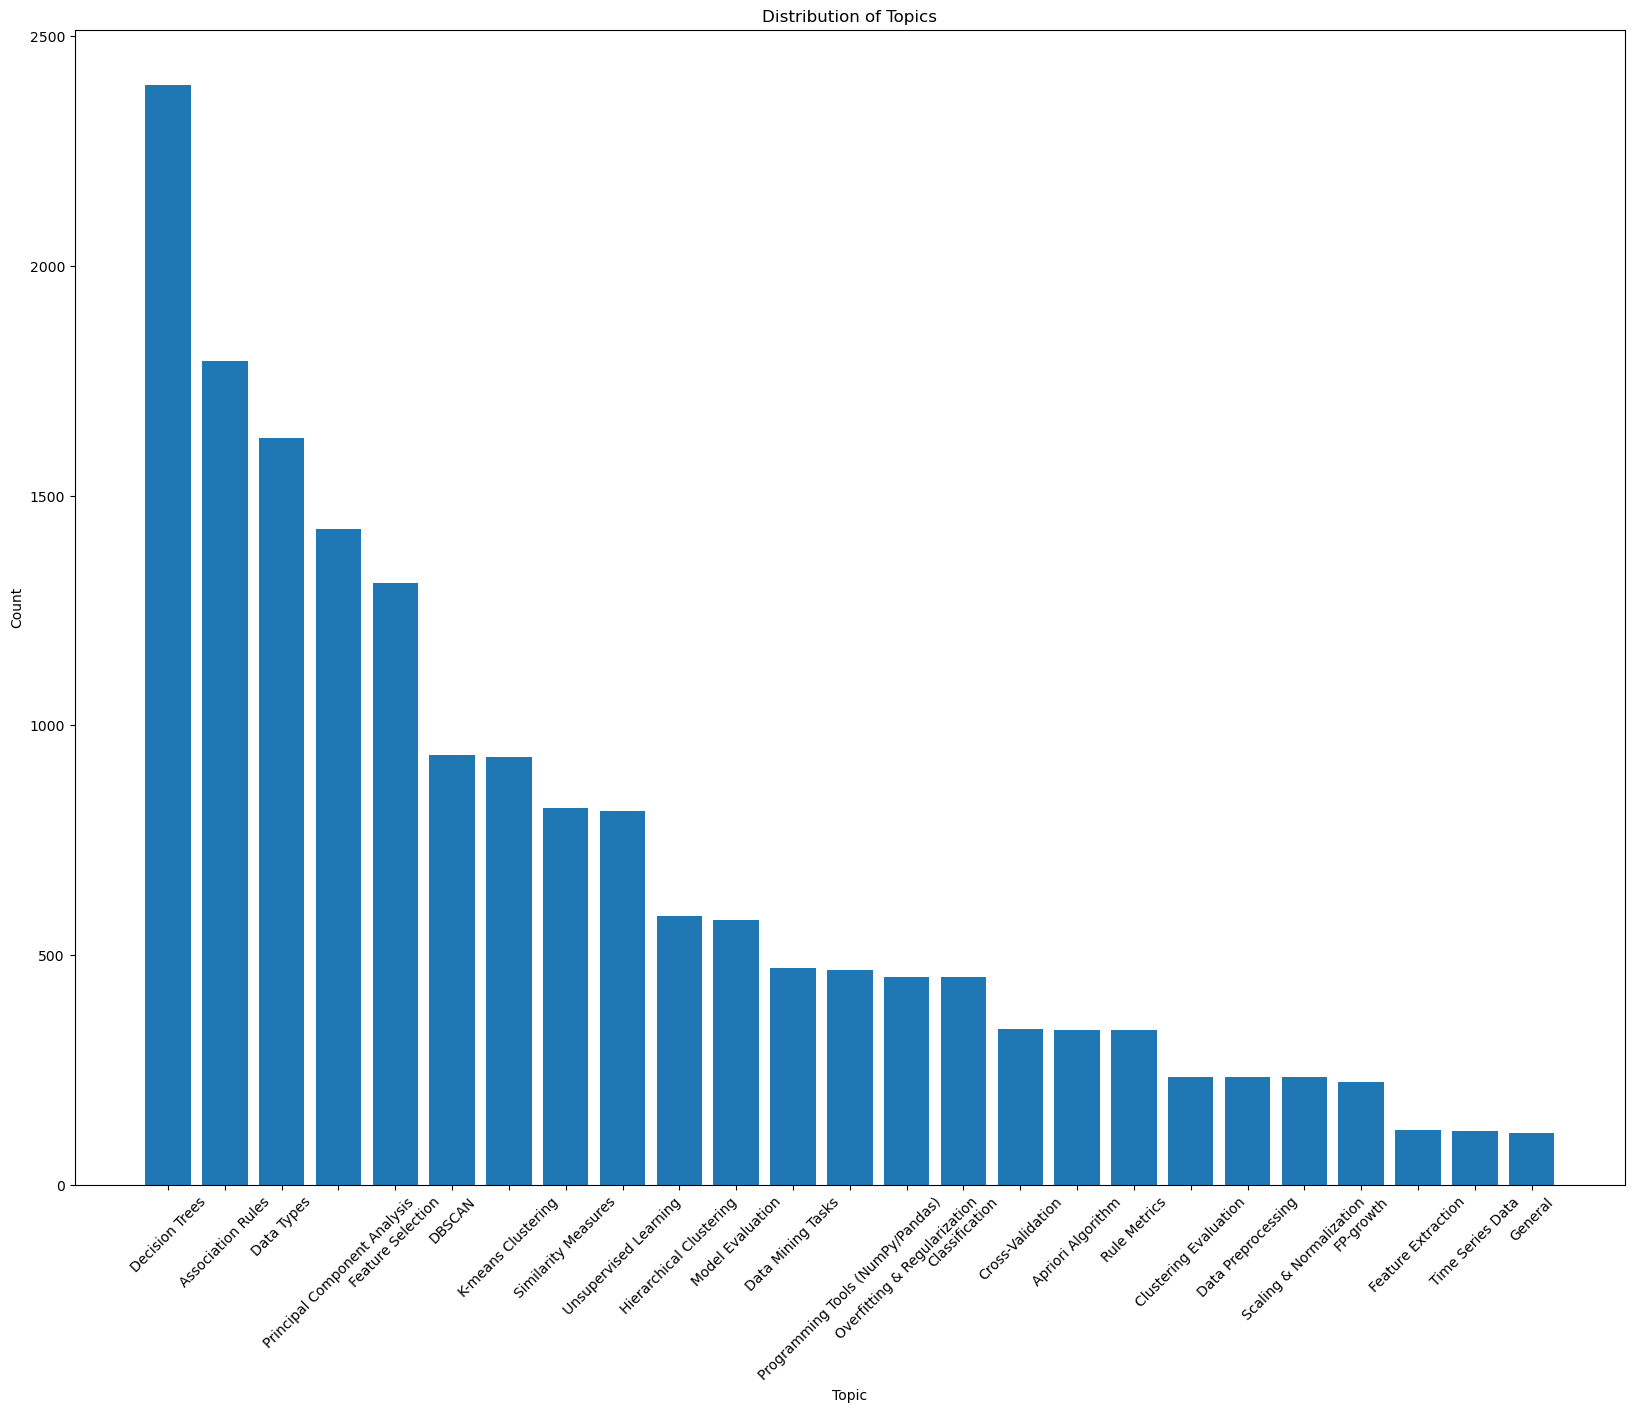

In [15]:
# vizualize the distribution of topics
topic_counts = df["topic"].value_counts()
plt.figure(figsize=(20, 15))
plt.bar(topic_counts.index, topic_counts.values)
plt.xlabel("Topic")
plt.ylabel("Count")
plt.title("Distribution of Topics")
plt.xticks(rotation=45)
plt.show()

- distribution of correct/incorrect

In [24]:
correct_counts = df["correct"].value_counts()
correct_percent = (correct_counts / len(df) * 100).round(2)
print(pd.DataFrame({"count": correct_counts, "percent": correct_percent}))

         count  percent
correct                
1        13134    75.74
0         4206    24.26


- Diffuculty distribution

In [18]:
difficulty_counts = df["difficulty"].value_counts()
print(difficulty_counts)

difficulty
easy      12583
medium     2546
hard       2211
Name: count, dtype: int64


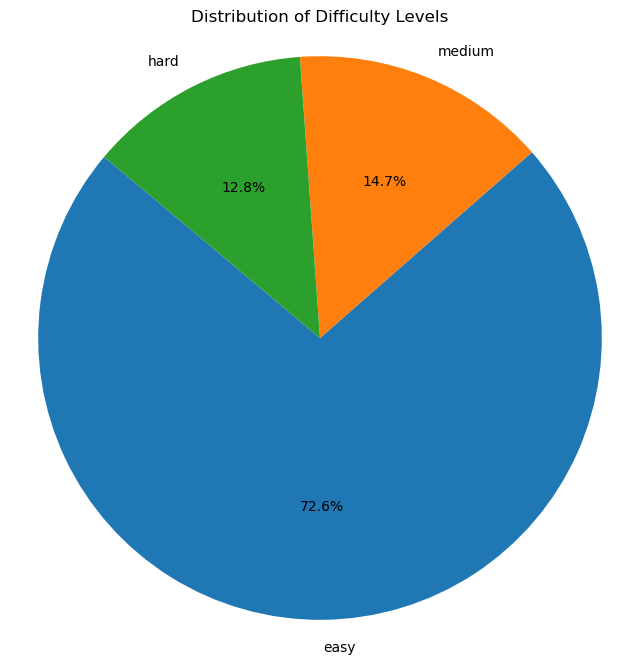

In [19]:
#make a pie chart of the distribution of difficulty levels
plt.figure(figsize=(8, 8))
plt.pie(difficulty_counts.values, labels=difficulty_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Distribution of Difficulty Levels")
plt.axis("equal")
plt.show()

- Describing response time

In [ ]:
df["Response Time"].describe()

count    17340.000000
mean     18913.771799
std       6608.463551
min       6361.000000
25%      14174.000000
50%      16575.000000
75%      23808.000000
max      46882.000000
Name: Response Time, dtype: float64

# 2. Feature engineering & Target creation

- In this section we'll engineer the features needed for the knowledge estimatior in order to predict correctly the student level.
  - Note : The following created features are cummulative and computed up to the current row in order to ensure that no data leakage happens

| Feature | Description |
|---|---|
| `global_correctness` | Overall accuracy so far (cumulative)  => running mean of `correct` column up to current interaction |
| `topic_correctness` | Accuracy within the current question's topic (cumulative) => mean of `correct` for same topic up to current row |
| `easy_correct_avg` | Accuracy on easy questions (cumulative) => mean of `correct` for difficulty='easy' up to current row |
| `medium_correct_avg` | Same as as for easy but for `medium` |
| `hard_correct_avg` | Same as as for easy but for `hard` |
| `avg_response_time` | Rolling mean of `Response Time` so far => cumulative average response time in milliseconds |
| `questions_answered_so_far` | Count of interactions before current row => total questions seen by student up to this point |
| `difficulty_encoded` | Current question's difficulty as integer: Easy=1, Medium=2, Hard=3 |

The **Target** would be a 3-class knowledge level (Beginner, Intermediate, Advanced) 

### 2.1 Sorting by the student ID while preserving the same order of interactions

In [25]:
df_sorted = df.sort_values(
    by=['Student ID'],
    kind='stable'          # stable sort preserves original row order within each student group
).reset_index(drop=True)


### 2.2 Creating the function to compute all the cummulative features 

- Note that the fallback values for the accuracy metrics are 0.5 to represent neutal state (50-50 chance)

In [27]:
def compute_features(df,row_idx):
    current_student=df.loc[row_idx, 'Student ID']
    current_topic=df.loc[row_idx, 'topic']
    current_difficulty=df.loc[row_idx, 'difficulty']
    difficulty_map={"easy": 1, "medium": 2, "hard": 3}
    encoded_difficulty=difficulty_map.get(current_difficulty, 2)

    student_history = df[(df['Student ID'] == current_student) & (df.index < row_idx)]

    if len(student_history)==0:
        return{
            'global_correctness': 0.5,
            'topic_correctness': 0.5,
            'difficulty_correctness': 0.5,
            'easy_correct_avg': 0.5,
            'medium_correct_avg': 0.5,
            'hard_correct_avg': 0.5,
            'avg_response_time': 0.0,
            'questions_answered_so_far': 0,
            'encoded_difficulty': encoded_difficulty
        }
    
    global_correctness = student_history['correct'].mean()
    topic_history=student_history[student_history['topic']==current_topic]
    topic_correctness=topic_history['correct'].mean() if len(topic_history)>0 else 0.5
    easy_correct_avg=student_history[student_history['difficulty']=='easy']['correct'].mean() if len(student_history[student_history['difficulty']=='easy'])>0 else 0.5
    medium_correct_avg=student_history[student_history['difficulty']=='medium']['correct'].mean() if len(student_history[student_history['difficulty']=='medium'])>0 else 0.5
    hard_correct_avg=student_history[student_history['difficulty']=='hard']['correct'].mean() if len(student_history[student_history['difficulty']=='hard'])>0 else 0.5
    avg_response_time=student_history['Response Time'].mean()
    questions_answered_so_far=len(student_history)

    return{
        'global_correctness': global_correctness,
        'topic_correctness': topic_correctness,
        'difficulty_correctness': (easy_correct_avg + medium_correct_avg + hard_correct_avg) / 3,
        'easy_correct_avg': easy_correct_avg,
        'medium_correct_avg': medium_correct_avg,
        'hard_correct_avg': hard_correct_avg,
        'avg_response_time': avg_response_time,
        'questions_answered_so_far': questions_answered_so_far,
        'encoded_difficulty': encoded_difficulty
    }


### 2.3 Calculating the features

- The above created function would be used in real time testing nd could not be used for filling all the rows in our dataset for training(because of high complexity)

- The following will create all the cummulative features for our dataset 

In [28]:
print("Computing cumulative features (vectorised)...")
# Work on a copy sorted stably by Student ID (interaction order preserved)
df_feat = df_sorted.copy()

# ── 1. difficulty_encoded (Current question property) ─────────────────────────
difficulty_map = {"easy": 1, "medium": 2, "hard": 3}
df_feat['difficulty_encoded'] = df_feat['difficulty'].map(difficulty_map).fillna(2).astype(int)

# ── Helper: cumulative mean shifted by 1 ──────────────────────────────────────
def shifted_expanding_mean(series, fill_val=0.5):
    # expanding().mean() calculates mean from 0..i
    # .shift(1) moves it so row i sees mean of 0..i-1
    return series.expanding().mean().shift(1).fillna(fill_val)

# ── 2. global_correctness ─────────────────────────────────────────────────────
df_feat['global_correctness'] = (
    df_feat.groupby('Student ID')['correct']
    .transform(lambda x: shifted_expanding_mean(x, 0.5))
)

# ── 3. avg_response_time ──────────────────────────────────────────────────────
df_feat['avg_response_time'] = (
    df_feat.groupby('Student ID')['Response Time']
    .transform(lambda x: shifted_expanding_mean(x, 0.0))
)

# ── 4. questions_answered_so_far ──────────────────────────────────────────────
df_feat['questions_answered_so_far'] = (
    df_feat.groupby('Student ID').cumcount()
)

# ── 5. topic_correctness ──────────────────────────────────────────────────────
df_feat['topic_correctness'] = (
    df_feat.groupby(['Student ID', 'topic'])['correct']
    .transform(lambda x: shifted_expanding_mean(x, 0.5))
)

# ── 6. easy_correct_avg / medium_correct_avg / hard_correct_avg ───────────────
for diff_val in ['easy', 'medium', 'hard']:
    col_name = f'{diff_val}_correct_avg'
    
    # Create a temporary series: correct value if difficulty matches, else NaN
    # expanding().mean() automatically ignores NaNs
    df_feat[col_name] = (
        df_feat.assign(temp_corr=np.where(df_feat['difficulty'] == diff_val, df_feat['correct'], np.nan))
        .groupby('Student ID')['temp_corr']
        .transform(lambda x: shifted_expanding_mean(x, 0.5))
    )

# ── 7. difficulty_correctness (Average of the 3 difficulty benchmarks) ────────
df_feat['difficulty_correctness'] = (
    df_feat['easy_correct_avg'] + 
    df_feat['medium_correct_avg'] + 
    df_feat['hard_correct_avg']
) / 3


# Verification
feat_cols = [
    'Student ID', 'difficulty_encoded', 'global_correctness', 'topic_correctness', 
    'difficulty_correctness', 'easy_correct_avg', 'medium_correct_avg', 
    'hard_correct_avg', 'avg_response_time', 'questions_answered_so_far'
]

print(f"\nSample (first 5 rows):")
print(df_feat[feat_cols].head().to_string())

Computing cumulative features (vectorised)...

Sample (first 5 rows):
     Student ID  difficulty_encoded  global_correctness  topic_correctness  difficulty_correctness  easy_correct_avg  medium_correct_avg  hard_correct_avg  avg_response_time  questions_answered_so_far
0  0Hpj01paAdfZ                   3            0.500000           0.500000                0.500000          0.500000                 0.5               0.5               0.00                          0
1  0Hpj01paAdfZ                   1            0.000000           0.500000                0.333333          0.500000                 0.5               0.0           24498.00                          1
2  0Hpj01paAdfZ                   1            0.500000           1.000000                0.500000          1.000000                 0.5               0.0           16362.50                          2
3  0Hpj01paAdfZ                   1            0.333333           0.500000                0.333333          0.500000          

### 2.4 Deriving the target feature ``Level``

 score = (W1 * global_correctness) + (W2 * hard_correct_avg) - (W3 * avg_response_time) 

- Note: avg_response_time is inverted and normalized so higher is better to pinalize guessing

In [ ]:
def derive_label(df, w1=0.5, w2=0.3, w3=0.2):
    
    # 1. Extract the Final State for each student to define their "True Level"
    student_final_state = df.groupby('Student ID').agg({
        'global_correctness': 'last',
        'hard_correct_avg': 'last',
        'avg_response_time': 'last'
    })

    # 2. Normalize Response Time (Inverted)
    # 1.0 = Fastest student, 0.0 = Slowest student
    t_min = student_final_state['avg_response_time'].min()
    t_max = student_final_state['avg_response_time'].max()
    student_final_state['normalized_inv_time'] = 1 - (
        (student_final_state['avg_response_time'] - t_min) / (t_max - t_min + 1e-9)
    )

    # 3. Calculate Final Mastery Score
    student_final_state['score'] = (
        (w1 * student_final_state['global_correctness']) +
        (w2 * student_final_state['hard_correct_avg']) +
        (w3 * student_final_state['normalized_inv_time'])
    )

    # 4. Create 3-class Labels using Percentiles (Quantiles) for balanced distribution
    student_final_state['knowledge_level'] = pd.qcut(
        student_final_state['score'],
        q=3,
        labels=['Beginner', 'Intermediate', 'Advanced']
    )

    return student_final_state[['score', 'knowledge_level']]
